# IMDB Movie Review Sentiment — EDA & Feature Engineering

This notebook explores the **IMDB Movie Review dataset** (50,000 labelled
reviews, binary sentiment classification) and prepares cleaned features for
an upcoming neural network implementation assignment.

**Files used:** `Train.csv` (40,000 rows), `Valid.csv` (5,000 rows), `Test.csv` (5,000 rows),
each with two columns: `text` and `label` (0 = negative, 1 = positive).

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
import os

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

os.makedirs("figures", exist_ok=True)

DATA_DIR = r"C:\Users\ybaav\OneDrive\Desktop\Week 2 AD\moviesentiment"
print(f"Using data directory: {DATA_DIR}")

Using data directory: c:\Users\ybaav\OneDrive\Desktop\Week 2 AD\moviesentiment


## 1. Load the data

In [ ]:
if 'pd' not in globals():
    import pandas as pd
    import os

DATA_DIR = r"C:\Users\ybaav\OneDrive\Desktop\Week 2 AD\moviesentiment"

print(f"Using data directory: {DATA_DIR}")
for file_name in ["Train.csv", "Valid.csv", "Test.csv"]:
    path = os.path.join(DATA_DIR, file_name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}. Put the CSV files in '{DATA_DIR}' or update DATA_DIR.")

train = pd.read_csv(os.path.join(DATA_DIR, "Train.csv"))
valid = pd.read_csv(os.path.join(DATA_DIR, "Valid.csv"))
test  = pd.read_csv(os.path.join(DATA_DIR, "Test.csv"))

for df in (train, valid, test):
    df['label'] = df['label'].astype(int)

print("Train:", train.shape, " Valid:", valid.shape, " Test:", test.shape)
train.head()

Using data directory: c:\Users\ybaav\OneDrive\Desktop\Week 2 AD\moviesentiment
Train: (40000, 2)  Valid: (5000, 2)  Test: (5000, 2)


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


## 2. Data quality checks

Check each split for missing values, duplicate reviews, and class balance.

In [3]:
for name, df in [('Train', train), ('Valid', valid), ('Test', test)]:
    print(f"--- {name} ---")
    print("Missing values:\n", df.isna().sum().to_dict())
    print("Duplicate texts:", df.duplicated(subset=['text']).sum())
    print("Class balance:\n", df['label'].value_counts(normalize=True).to_dict())
    print()

--- Train ---
Missing values:
 {'text': 0, 'label': 0}
Duplicate texts: 277
Class balance:
 {0: 0.500475, 1: 0.499525}

--- Valid ---
Missing values:
 {'text': 0, 'label': 0}
Duplicate texts: 2
Class balance:
 {1: 0.5028, 0: 0.4972}

--- Test ---
Missing values:
 {'text': 0, 'label': 0}
Duplicate texts: 5
Class balance:
 {1: 0.501, 0: 0.499}



**Observation:** No missing values in any split. Train.csv has 277 duplicate
reviews out of 40,000 (~0.7%) — common in scraped data, not significant enough
to warrant removal. All three splits are almost perfectly balanced (~50/50).

## 3. Class balance visualization

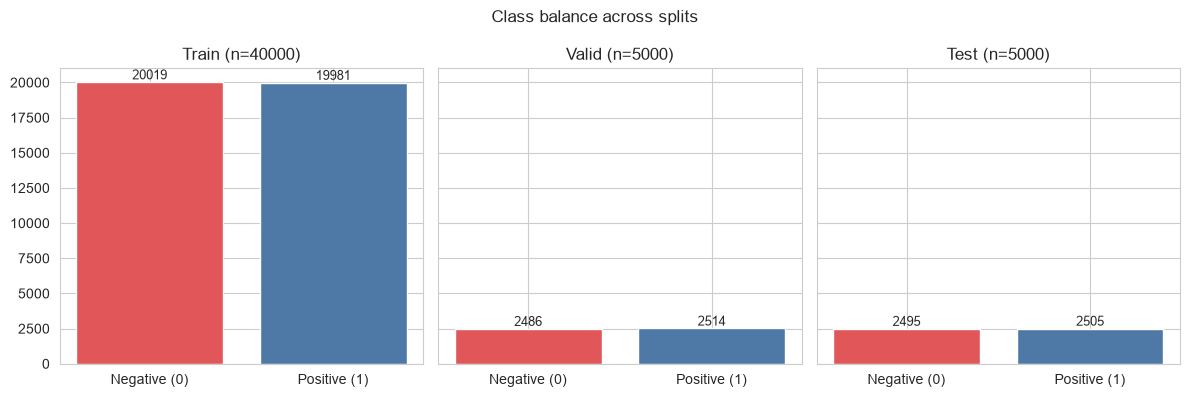

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (name, df) in zip(axes, [('Train', train), ('Valid', valid), ('Test', test)]):
    counts = df['label'].value_counts().sort_index()
    ax.bar(['Negative (0)', 'Positive (1)'], counts.values, color=['#e15759', '#4e79a7'])
    ax.set_title(f"{name} (n={len(df)})")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, str(v), ha='center', fontsize=9)
fig.suptitle("Class balance across splits")
fig.tight_layout()
fig.savefig("figures/01_class_balance.png")
plt.show()

Because the classes are balanced, **accuracy is a valid and sufficient
evaluation metric** for the coming neural network assignment; no
class re-weighting or resampling is required.

## 4. Review length distribution

Review length is measured in characters and whitespace-separated words.
We also flag whether a review still contains the raw `<br />` HTML tag
left over from scraping IMDB.

In [5]:
def add_len_features(df):
    df = df.copy()
    df['char_len'] = df['text'].str.len()
    df['word_len'] = df['text'].str.split().str.len()
    df['has_br'] = df['text'].str.contains(r'<br\s*/?>', regex=True)
    return df

train = add_len_features(train)
valid = add_len_features(valid)
test  = add_len_features(test)

print(train['word_len'].describe())
print(f"\n<br /> tag present in {train['has_br'].mean()*100:.1f}% of training reviews")

count    40000.000000
mean       231.339250
std        171.194123
min          4.000000
25%        126.000000
50%        173.000000
75%        282.000000
max       2470.000000
Name: word_len, dtype: float64

<br /> tag present in 58.4% of training reviews


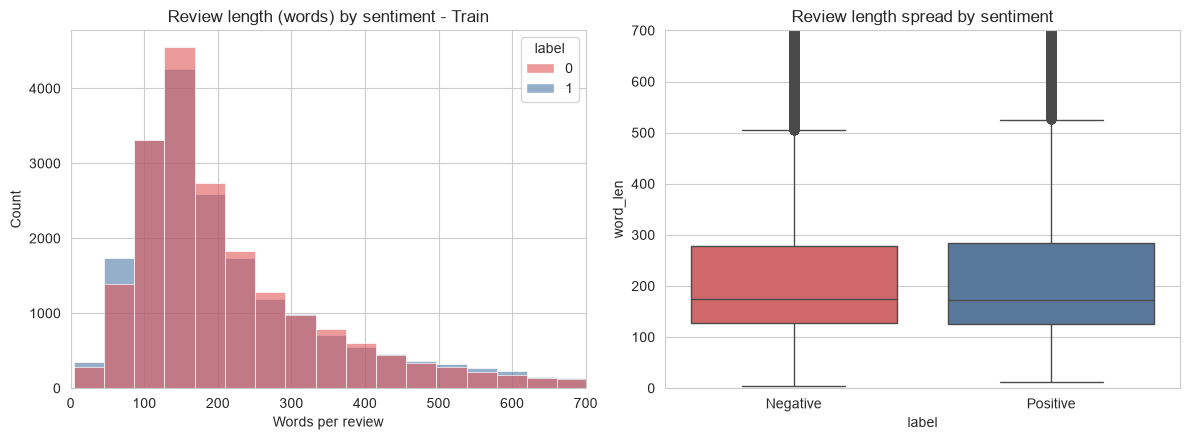

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(data=train, x='word_len', hue='label', bins=60, ax=axes[0],
             palette={0: '#e15759', 1: '#4e79a7'}, alpha=0.6)
axes[0].set_xlim(0, 700)
axes[0].set_title("Review length (words) by sentiment - Train")
axes[0].set_xlabel("Words per review")

sns.boxplot(data=train, x='label', y='word_len', hue='label', ax=axes[1],
            palette={0: '#e15759', 1: '#4e79a7'}, legend=False)
axes[1].set_ylim(0, 700)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Negative', 'Positive'])
axes[1].set_title("Review length spread by sentiment")
fig.tight_layout()
fig.savefig("figures/02_length_distribution.png")
plt.show()

In [7]:
corr = train[['word_len', 'label']].corr().iloc[0, 1]
print(f"Correlation between word length and label: {corr:.4f}")

Correlation between word length and label: 0.0125


Review length is **right-skewed** (median 173 words, max 2,470 words) and the
correlation between raw word count and sentiment label is essentially zero
(r ≈ 0.01) — length alone carries almost no predictive signal. The model
will need to learn from word content and context, not length.

## 5. Choosing a sequence length for padding

Neural network text models need a fixed input length. We plot the cumulative
distribution of review length to pick a sensible truncation/padding cut-off.

Word-length percentiles: {50: np.float64(173.0), 75: np.float64(282.0), 90: np.float64(452.0), 95: np.float64(590.0), 99: np.float64(903.0), 100: np.float64(2470.0)}


C:\Users\ybaav\AppData\Local\Temp\ipykernel_5440\3280270260.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


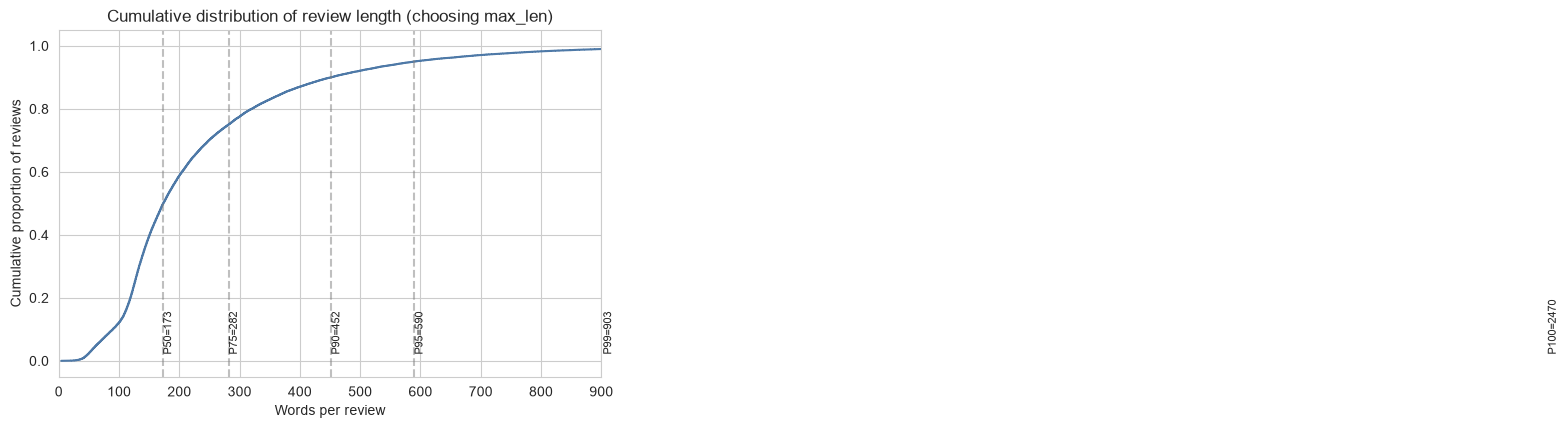

In [8]:
percentiles = [50, 75, 90, 95, 99, 100]
pct_vals = np.percentile(train['word_len'], percentiles)
print("Word-length percentiles:", dict(zip(percentiles, pct_vals)))

fig, ax = plt.subplots(figsize=(7, 4.5))
sorted_lens = np.sort(train['word_len'].values)
cum = np.arange(1, len(sorted_lens) + 1) / len(sorted_lens)
ax.plot(sorted_lens, cum, color='#4e79a7')
for pp, v in zip(percentiles, pct_vals):
    ax.axvline(v, color='gray', linestyle='--', alpha=0.5)
    ax.text(v, 0.02, f"P{pp}={int(v)}", rotation=90, fontsize=8, va='bottom')
ax.set_xlim(0, 900)
ax.set_xlabel("Words per review")
ax.set_ylabel("Cumulative proportion of reviews")
ax.set_title("Cumulative distribution of review length (choosing max_len)")
fig.tight_layout()
fig.savefig("figures/03_length_cdf.png")
plt.show()

~75-80% of reviews fall at or below 250-280 words. **A max sequence length of
250 tokens** is recommended: it retains the bulk of most reviews' content
while keeping padded sequences manageable for training.

## 6. Text cleaning (feature engineering)

Cleaning steps applied:
1. Strip leftover `<br />` HTML tags.
2. Remove URLs.
3. Keep only letters and apostrophes (preserve contractions like "don't").
4. Lower-case everything.
5. Collapse repeated whitespace.

For the descriptive word-frequency analysis below, we additionally remove
English stop-words and very short tokens. (Note: for the coming neural
network, stop-words are typically *kept* in the sequence fed to the
embedding layer, since word order/function words can carry useful signal —
they are only removed here to make the word-frequency/word-cloud analysis
more informative.)

In [9]:
STOPWORDS = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r"[^a-zA-Z']", ' ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_no_stop(text):
    return [w for w in text.split() if w not in STOPWORDS and len(w) > 2]

train['clean_text'] = train['text'].apply(clean_text)
train['tokens'] = train['clean_text'].apply(tokenize_no_stop)

print("Raw:    ", train['text'].iloc[0][:200])
print("\nCleaned:", train['clean_text'].iloc[0][:200])

Raw:     I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school watched. We played "Thunderbirds" before school, during lunch and after school. We all wanted to be Virgil or Scott. No

Cleaned: i grew up b watching and loving the thunderbirds all my mates at school watched we played thunderbirds before school during lunch and after school we all wanted to be virgil or scott no one wanted to 


## 7. Vocabulary size and coverage

After cleaning and stop-word removal, how many unique tokens are there, and
how much of the corpus is covered by the N most frequent tokens? This tells
us what embedding vocabulary size to use in the coming assignment.

In [10]:
all_tokens = Counter()
for toks in train['tokens']:
    all_tokens.update(toks)

total_tokens = sum(all_tokens.values())
sorted_counts = sorted(all_tokens.values(), reverse=True)
cum_cov = np.cumsum(sorted_counts) / total_tokens

print("Total unique tokens:", len(all_tokens))
print("Total token occurrences:", total_tokens)

coverage_by_topN = {}
for vocab_size in [1000, 2000, 5000, 10000, 20000, 30000]:
    coverage_by_topN[vocab_size] = float(cum_cov[vocab_size - 1])
    print(f"Top {vocab_size:>6} tokens cover {cum_cov[vocab_size - 1]*100:.1f}% of the corpus")

Total unique tokens: 107118
Total token occurrences: 4279209
Top   1000 tokens cover 54.9% of the corpus
Top   2000 tokens cover 66.3% of the corpus
Top   5000 tokens cover 79.9% of the corpus
Top  10000 tokens cover 88.1% of the corpus
Top  20000 tokens cover 94.1% of the corpus
Top  30000 tokens cover 96.4% of the corpus


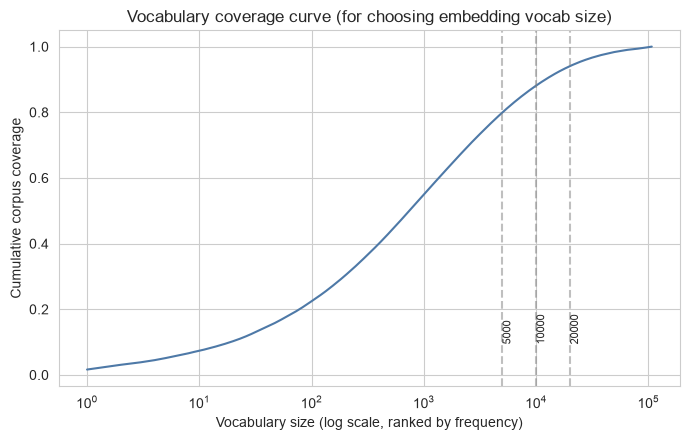

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(np.arange(1, len(cum_cov) + 1), cum_cov, color='#4e79a7')
ax.set_xscale('log')
ax.set_xlabel("Vocabulary size (log scale, ranked by frequency)")
ax.set_ylabel("Cumulative corpus coverage")
ax.set_title("Vocabulary coverage curve (for choosing embedding vocab size)")
for vs in [5000, 10000, 20000]:
    ax.axvline(vs, color='gray', ls='--', alpha=0.5)
    ax.text(vs, 0.1, f"{vs}", rotation=90, fontsize=8)
fig.tight_layout()
fig.savefig("figures/04_vocab_coverage.png")
plt.show()

**A vocabulary size of 20,000 words is recommended**: it covers ~94% of all
word occurrences while keeping the embedding matrix a manageable size.
Words outside this vocabulary can be mapped to an `<OOV>` token.

## 8. Most frequent words by class

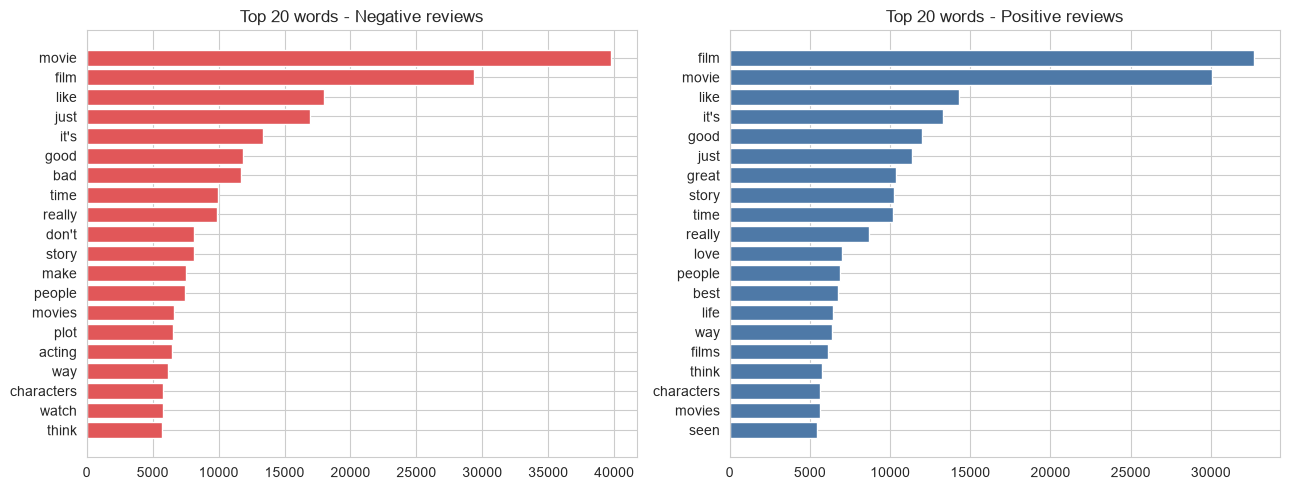

In [12]:
pos_tokens, neg_tokens = Counter(), Counter()
for toks, lab in zip(train['tokens'], train['label']):
    (pos_tokens if lab == 1 else neg_tokens).update(toks)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title, counter, color) in zip(axes, [
        ("Top 20 words - Negative reviews", neg_tokens, '#e15759'),
        ("Top 20 words - Positive reviews", pos_tokens, '#4e79a7')]):
    top = counter.most_common(20)
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(title)
fig.tight_layout()
fig.savefig("figures/05_top_words_by_class.png")
plt.show()

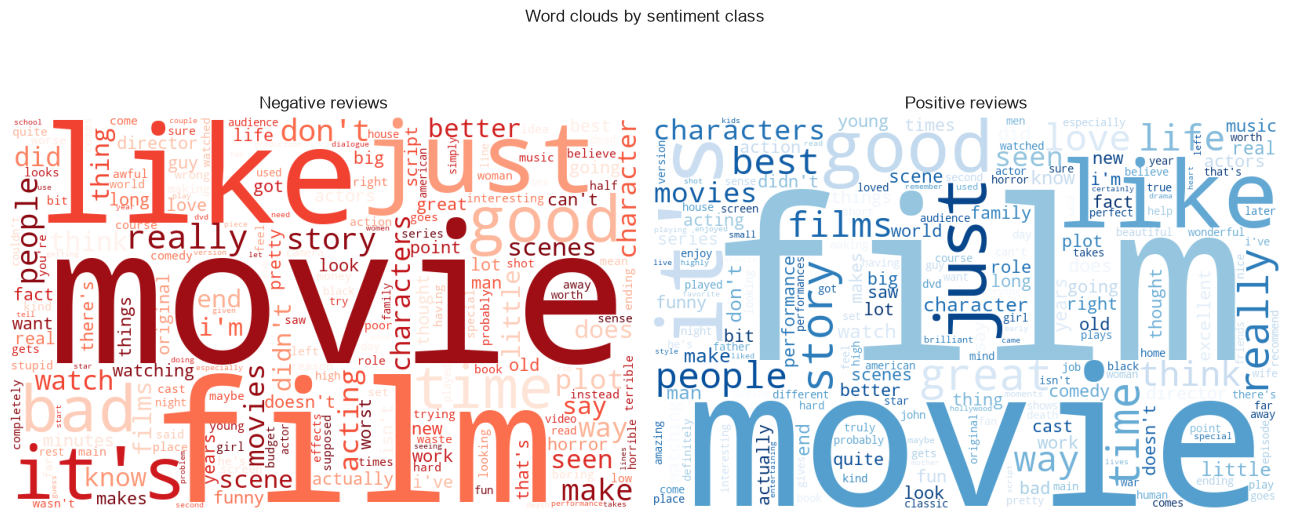

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
wc_neg = WordCloud(width=800, height=500, background_color='white', colormap='Reds').generate_from_frequencies(neg_tokens)
wc_pos = WordCloud(width=800, height=500, background_color='white', colormap='Blues').generate_from_frequencies(pos_tokens)
axes[0].imshow(wc_neg); axes[0].axis('off'); axes[0].set_title("Negative reviews")
axes[1].imshow(wc_pos); axes[1].axis('off'); axes[1].set_title("Positive reviews")
fig.suptitle("Word clouds by sentiment class")
fig.tight_layout()
fig.savefig("figures/06_wordclouds.png")
plt.show()

Both classes are dominated by generic movie-review vocabulary ("movie",
"film", "like"), but sentiment-bearing words appear clearly further down the
frequency ranking (e.g. "bad", "worst" for negative; "great", "best", "love"
for positive).

## 9. Bigrams and discriminative phrases

Single words like "good" or "bad" can be misleading (e.g. "not good"), so we
also look at bigrams (two-word phrases), which capture some local word order
and negation context that a bag-of-unigrams misses.

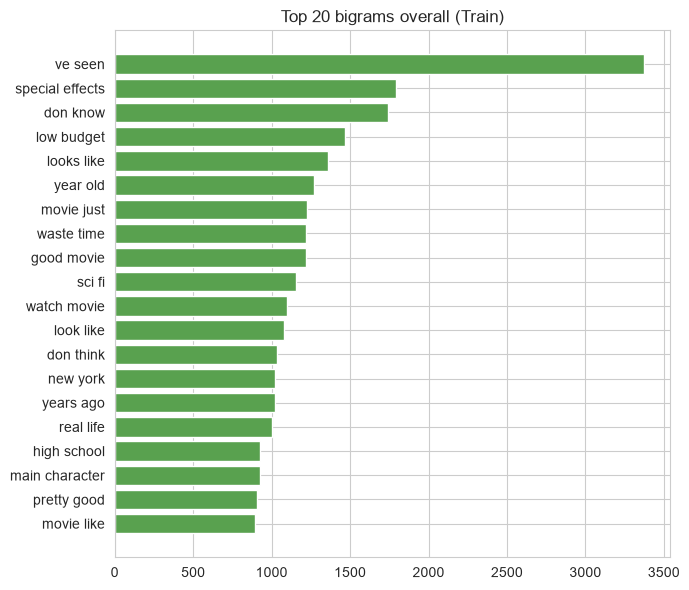

In [14]:
cv = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=5000, min_df=5)
X = cv.fit_transform(train['clean_text'])
bigram_counts = np.asarray(X.sum(axis=0)).ravel()
vocab = np.array(cv.get_feature_names_out())

top_overall_idx = bigram_counts.argsort()[::-1][:20]
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(vocab[top_overall_idx][::-1], bigram_counts[top_overall_idx][::-1], color='#59a14f')
ax.set_title("Top 20 bigrams overall (Train)")
fig.tight_layout()
fig.savefig("figures/07_top_bigrams.png")
plt.show()

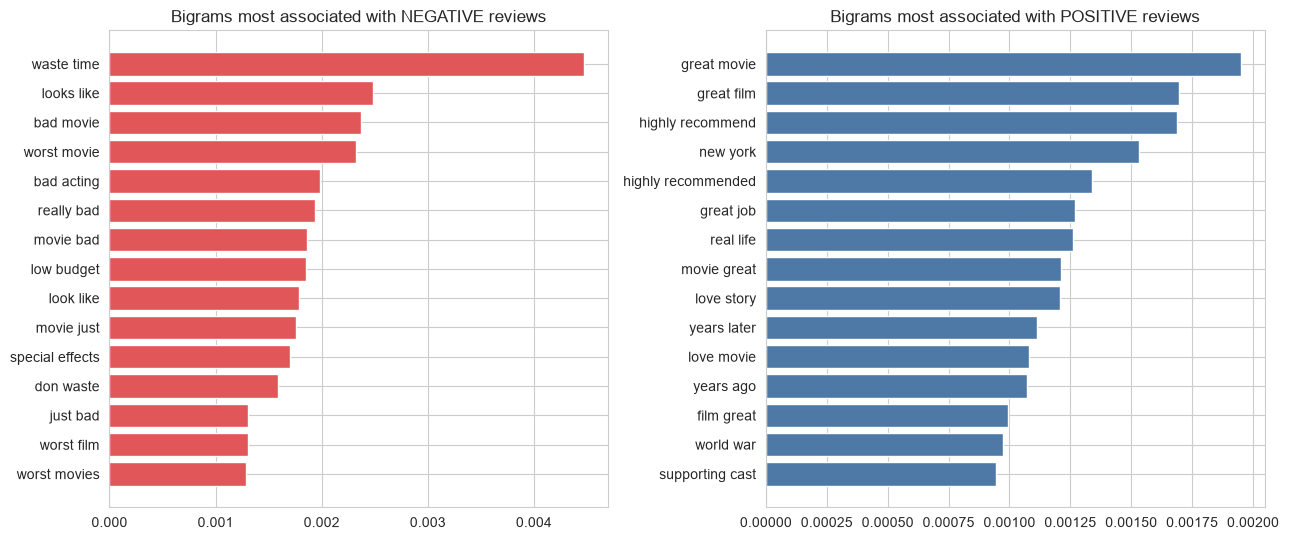

In [15]:
pos_mask = (train['label'] == 1).values
neg_mask = (train['label'] == 0).values
pos_counts = np.asarray(X[pos_mask].sum(axis=0)).ravel()
neg_counts = np.asarray(X[neg_mask].sum(axis=0)).ravel()

pos_rate = pos_counts / pos_counts.sum()
neg_rate = neg_counts / neg_counts.sum()
diff = pos_rate - neg_rate
top_pos_idx = diff.argsort()[::-1][:15]
top_neg_idx = diff.argsort()[:15]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].barh(vocab[top_neg_idx][::-1], -diff[top_neg_idx][::-1], color='#e15759')
axes[0].set_title("Bigrams most associated with NEGATIVE reviews")
axes[1].barh(vocab[top_pos_idx][::-1], diff[top_pos_idx][::-1], color='#4e79a7')
axes[1].set_title("Bigrams most associated with POSITIVE reviews")
fig.tight_layout()
fig.savefig("figures/08_discriminative_bigrams.png")
plt.show()

Clearly polar phrases emerge: **"waste time"**, **"bad movie"**, **"worst
movie"** for negative reviews vs. **"great movie"**, **"highly recommend"**,
**"love story"** for positive reviews. This confirms the dataset has strong,
learnable lexical signal, supporting an embedding-based neural network for
this task.

## 10. Export cleaned datasets for the neural network assignment

We apply the same cleaning function to all three splits and save the result,
ready to be fed into a Keras/PyTorch tokenizer + embedding pipeline.

In [16]:
valid['clean_text'] = valid['text'].apply(clean_text)
test['clean_text']  = test['text'].apply(clean_text)

os.makedirs("data", exist_ok=True)
train[['clean_text', 'label']].rename(columns={'clean_text': 'text'}).to_csv("data/train_clean.csv", index=False)
valid[['clean_text', 'label']].rename(columns={'clean_text': 'text'}).to_csv("data/valid_clean.csv", index=False)
test[['clean_text', 'label']].rename(columns={'clean_text': 'text'}).to_csv("data/test_clean.csv", index=False)

print("Saved data/train_clean.csv, data/valid_clean.csv, data/test_clean.csv")

Saved data/train_clean.csv, data/valid_clean.csv, data/test_clean.csv


## 11. Summary of key findings

- The dataset is clean (no missing values) and perfectly balanced across
  classes in all three splits, so **accuracy is an appropriate metric** and
  no class re-weighting is required.
- **58.4%** of raw reviews contain HTML artifacts (`<br />`) that must be
  stripped before tokenization.
- Review length is right-skewed (median 173 words) and only weakly
  correlated with sentiment (r ≈ 0.012) — the network must learn from
  content, not length.
- A **max sequence length of ~250 tokens** and a **vocabulary size of
  ~20,000 words** are recommended, balancing coverage against computational
  cost.
- Word-frequency and bigram analysis show strong, human-interpretable
  lexical signal separating the two classes, supporting the choice of an
  embedding-based neural network (RNN/CNN) for the coming assignment.

| Parameter | Recommended value | Rationale |
|---|---|---|
| Vocabulary size | 20,000 | Covers ~94% of token occurrences |
| Max sequence length | 250 tokens | Covers ~75-80% of reviews without excessive padding |
| OOV handling | Map to `<OOV>` token | 107k unique tokens; long tail must be handled |
| Padding | Post-padding, post-truncation | Standard for RNN/embedding pipelines |
| Class weighting | None needed | Classes are balanced ~50/50 |